# Imports

In [1]:
#set path to DeePEn
import os.path

os.chdir("path to DeePEn")

In [2]:
#import dependencies
import copy
import requests
import zipfile
import io
import json
import math
import os
import subprocess
import sys

import numpy as np
import pandas as pd

from scipy import stats
from scipy.interpolate import make_interp_spline

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.pyplot import cm
import matplotlib.ticker as mtick

import seaborn as sns

In [3]:
# import methods
sys.path.append('./utils')
from DeePEn_evaluate import get_cutoff, load_results, calc_spearman_depthwise, calc_metric_depth
from DeePEn_analyse import plot_multi_model_multi_metric_DeePEn, table_multi_model_multi_metric_DeePEn, mean_confidence_interval_individual

In [4]:
# run prepare_data.py if the splits were not created yet
if not os.path.isdir('./data/splits'):
    subprocess.run(['python', './data/prepare_data.py'])

In [6]:
# Check: If ./results exists, contains SOM zip shards, and does NOT contain SOM directory, unzip
main_zip_1 = './results/SOM_1.zip'
main_zip_2 = './results/SOM_2.zip'
main_dir = './results/SOM'

def unzip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        zipf.extractall(extract_to)

if os.path.isdir('./results') and os.path.isfile(main_zip_1) and os.path.isfile(main_zip_2) and not os.path.isdir(main_dir):
    unzip(main_zip_1, main_dir)
    unzip(main_zip_2, main_dir)
    print(f'Extracted {main_zip_1.split("/")[-1]} and {main_zip_2.split("/")[-1]} to {main_dir}')
elif os.path.isdir(main_dir):
    print(f'{main_dir} was already extracted previously')    
else:
    print(f'{main_zip} is missing')

./results/SOM was already extracted previously


# Create display items

In [6]:
# Get a list of all datasets in the directory
files = os.listdir("./data/splits")
files

['CAPSD_AAV2S_Sinai_2021',
 'GFP_AEQVI_Sarkisyan_2016',
 'HIS7_YEAST_Pokusaeva_2019',
 'PHOT_CHLRE_Chen_2023']

## Figures

### Fig. S1

In [7]:
def plot_depthwise(data, data_name, path):
    
    files = os.listdir(path)
    filtered_files = [f for f in files if data in f]

    depth = list(range(1,len(filtered_files)+1)) 
    
    dfs = []
    
    for d in depth:
        df = calc_spearman_depthwise(path, data, d)
        dfs.append(df)
        
    # Initialize the figure and subplots
    fig, ax = plt.subplots(figsize=(8, 3),dpi=300)

    color=cm.rainbow(np.linspace(0,1,9))
    
    color = color[len(color)-int(depth[-1]):]

    # First subplot
    for df, d, c in zip(dfs, depth, reversed(color)):
        if d == 1:
            name = str(d)
        else:
            name = "1 - " + str(d)
            
        ax.plot(df['x'], df['mean'], marker='o', markerfacecolor='none', c=c)
        ax.plot(df['x'][1:], df['mean'][1:], label=name, marker='o', c=c)

    ax.set_xticks([0, 1] + list(dfs[0]['x']))
    ax.set_xticklabels(["WT", 1] + list(dfs[0]['depth']))

    ax.set_xlim(1, df['x'].max())
    ax.set_ylim(0, 1)

    ax.set_xlabel('Mutation Depth')
    ax.set_ylabel('Spearman')

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = "Training depth")

    # Adjust layout and show the plot
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    ax.set_title(data_name)
    plt.show()

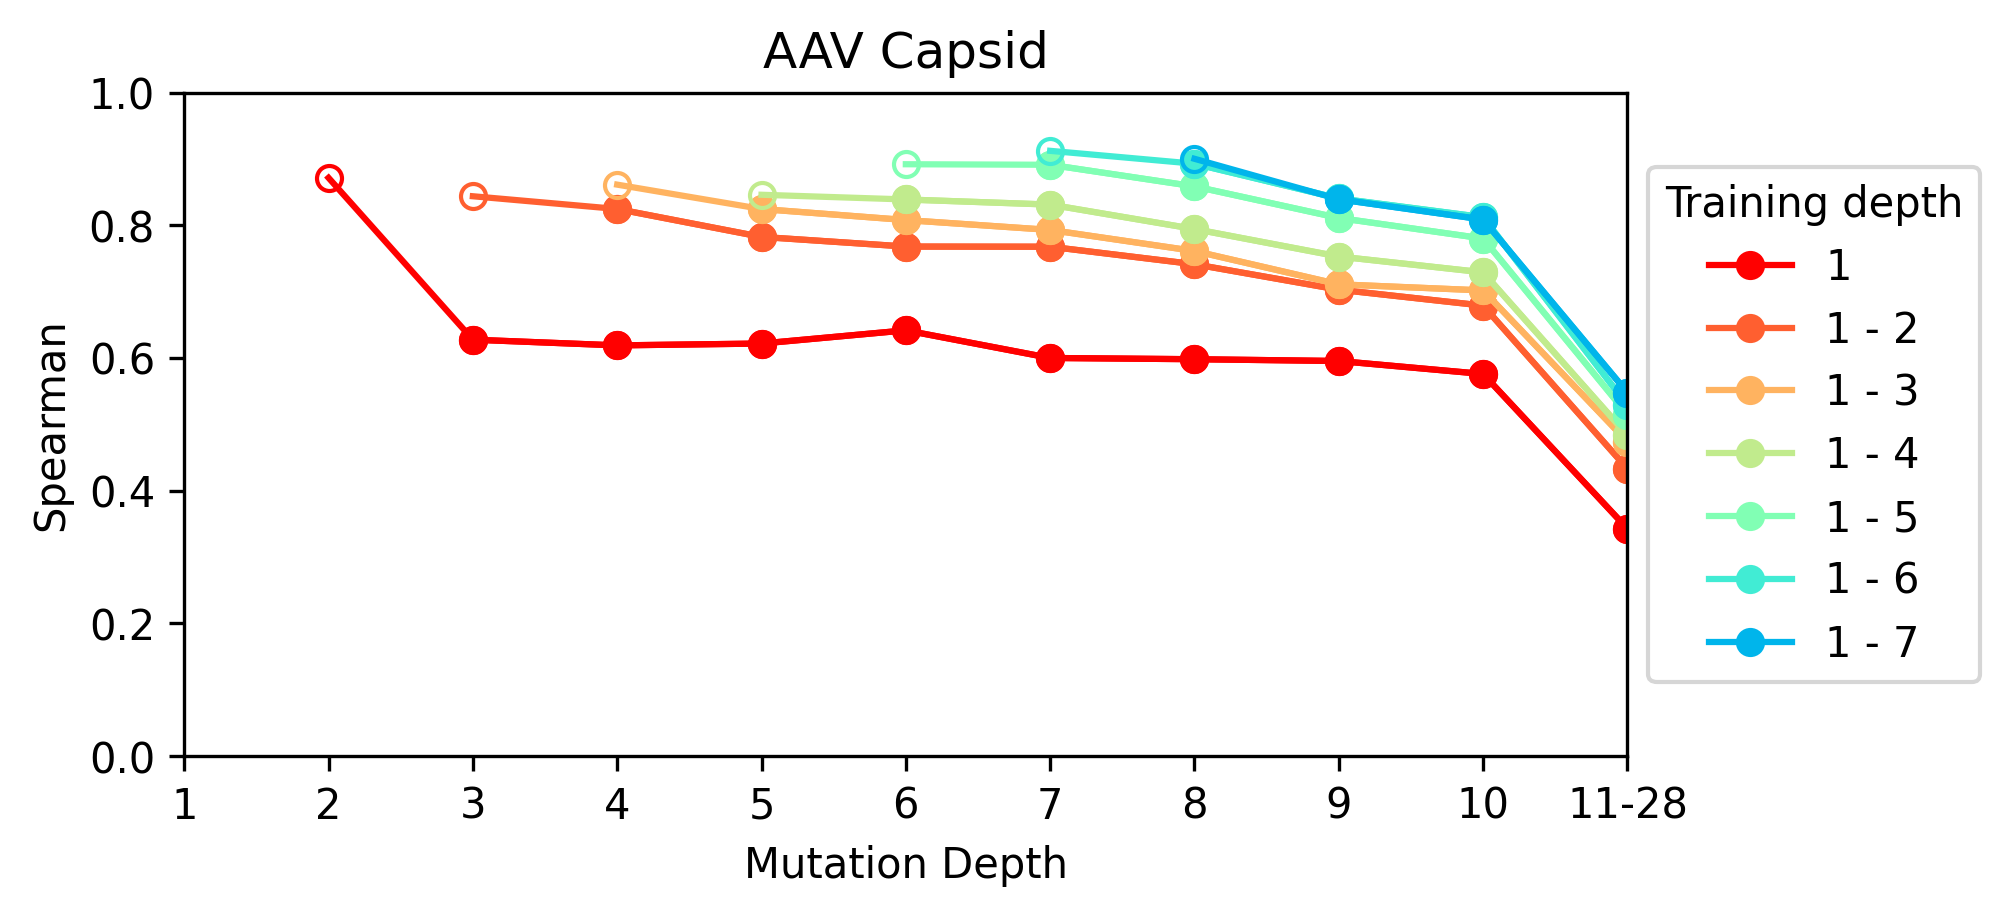

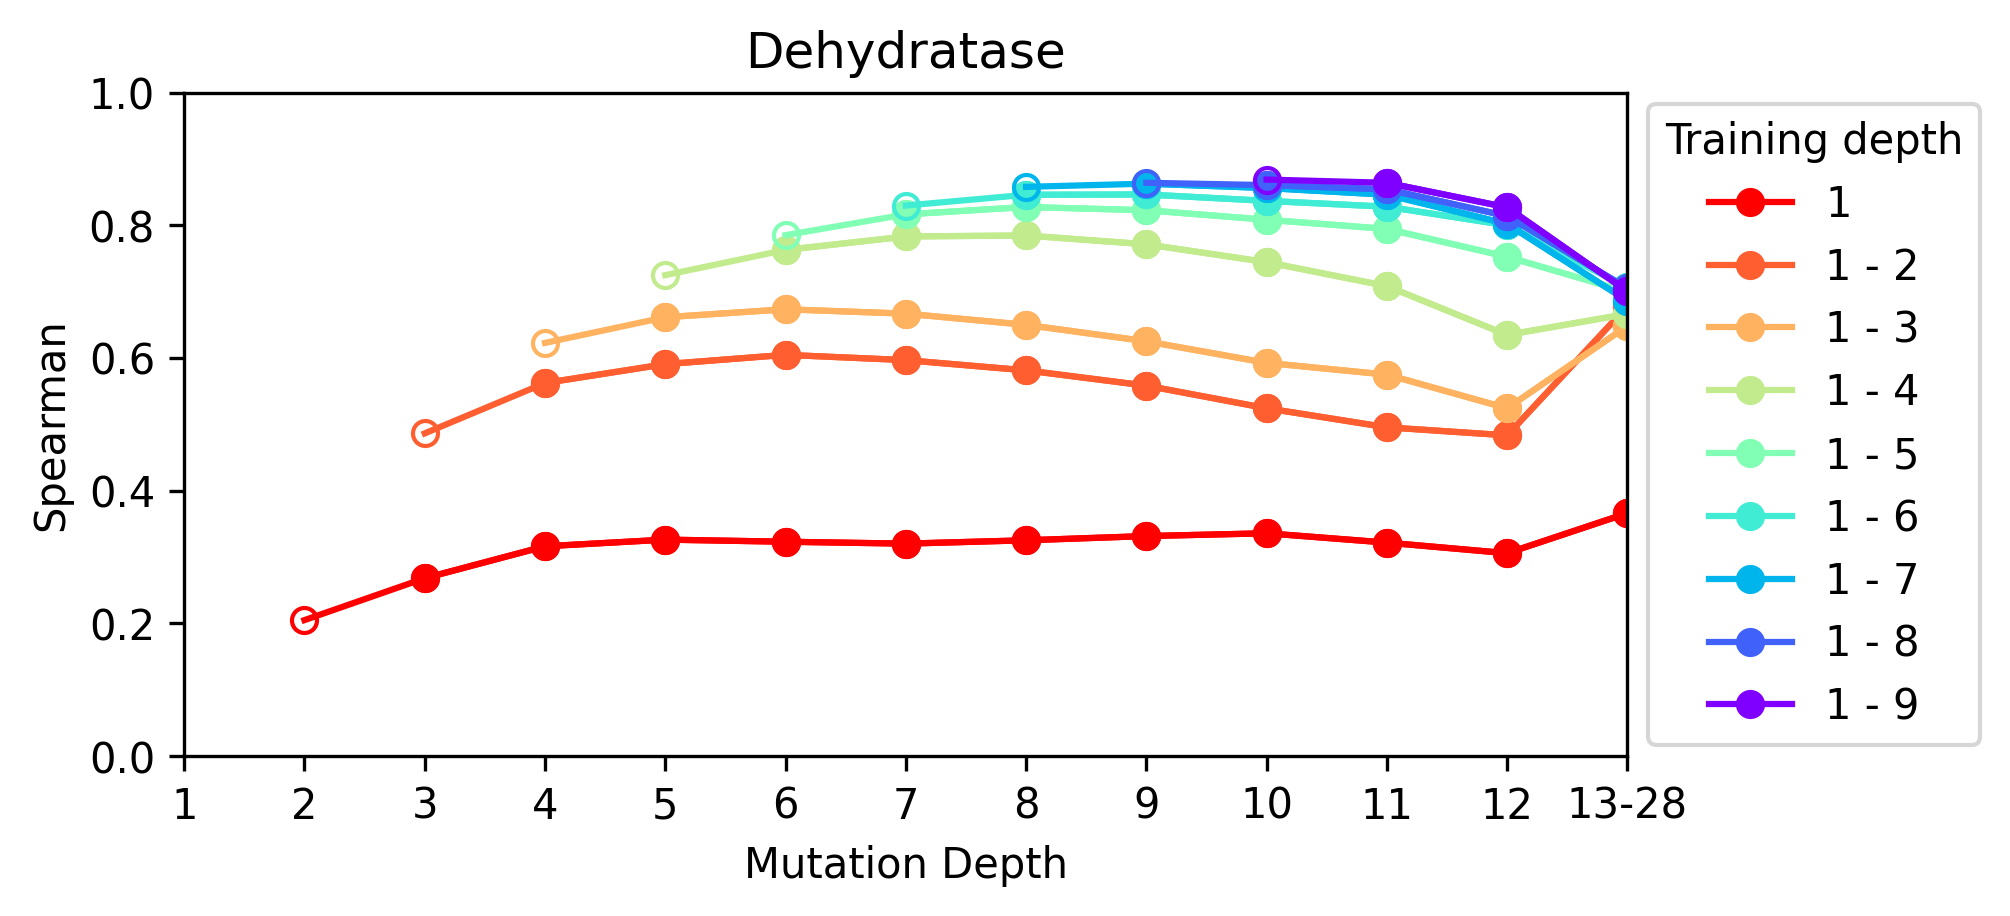

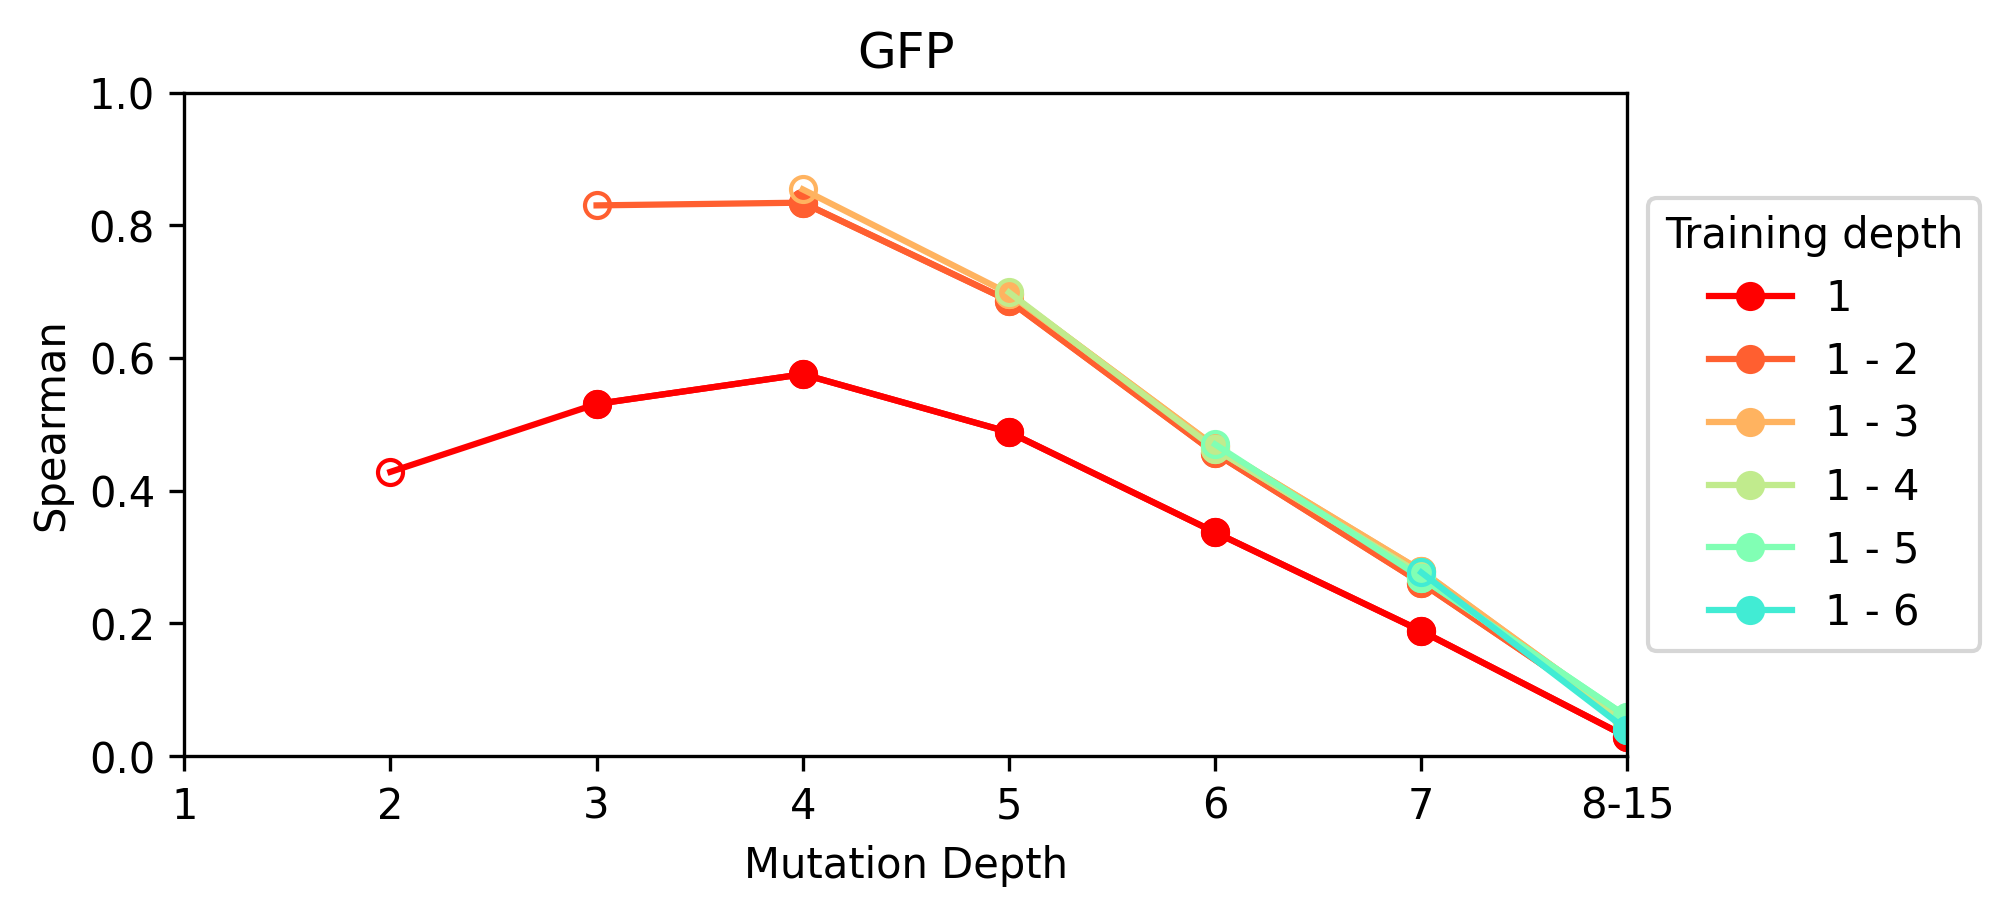

In [8]:
path_SOM_depthwise = "./results/SOM/PT5-LoRA Rank. Depthwise"

# plot depthwise for all but PHOT_CHLRE_Chen_2023 
for f, n in zip([files[0],files[2],files[1]], ["AAV Capsid", "Dehydratase", "GFP"]):
    plot_depthwise(f, n, path_SOM_depthwise)

### Figure S2

In [17]:
models = ['HBI',
         'OHE',
         'MAVE-NN add.',
         'MAVE-NN bb.',
         'PT5-LoRA Reg.',
         'PT5-LoRA Rank.',
         'PT5-Emb',
         'PT5-Emb evo',
         'METL-1D',
         'METL-3D']


In [18]:
df_metric = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_25", "NDCG@10"], aggregate = False)

In [19]:
res = pd.DataFrame(columns=["method","depth","seed","AUCPR", "spearman_func", "TOP_25", "NDCG@10"]) 

for k, met in enumerate(["AUCPR", "spearman_func", "TOP_25", "NDCG@10"]):

    dfs =  df_metric[k][0]                                             
    dfs_tail =  df_metric[k][1]

    for idx, (df, tail, m) in enumerate(zip(dfs, dfs_tail, models)):

        # Calculate mean for each individual model run (per seed)
        grouped = df.groupby(['data',"Seed"])
        df = grouped['value'].agg(['mean', 'count']).reset_index()
        seeds = df.Seed.unique().tolist()
        
        for s in seeds:
            mean_df = df[df.Seed == s]["mean"].mean()
            new_row = pd.DataFrame([{'method': m, 'seed': s, 'depth' : "shallow (5-9)", met : str(round(mean_df,3))}])
            res = pd.concat([res,new_row], ignore_index=True)
            
        grouped = tail.groupby(['data',"Seed"])
        tail = grouped['value'].agg(['mean', 'count']).reset_index()
        seeds = tail.Seed.unique().tolist()
        
        for s in seeds:
            mean_tail = tail[tail.Seed == s]["mean"].mean()
            new_row = pd.DataFrame([{'method': m, 'seed': s, 'depth' : "higher depth (10+)", met : str(round(mean_tail,3))}])
            res = pd.concat([res,new_row], ignore_index=True)

# Group by the identifier columns and apply the first non-null aggregation
res = res.groupby(['method', 'depth', "seed"], as_index=False).first()

# Convert the 'method' column to a categorical type with the specified order
res['method'] = pd.Categorical(res['method'], categories=models, ordered=True)

# Sort the DataFrame by the 'method' column
res = res.sort_values(by=['method', "depth"], ascending=[True, False]).reset_index(drop=True)
res.columns = ["method", "depth", "seed", 'AUCPR', 'Spearman', 'Top25%', 'NDCG@10%']
res

,method,depth,seed,AUCPR,Spearman,Top25%,NDCG@10%
0,HBI,shallow (5-9),1,0.629,0.206,0.242,0.569
1,HBI,higher depth (10+),1,0.301,0.14,0.087,0.276
2,OHE,shallow (5-9),1,0.515,0.002,0.126,0.37
3,OHE,shallow (5-9),2,0.531,0.052,0.16,0.441
4,OHE,shallow (5-9),3,0.502,-0.011,0.114,0.345
5,OHE,higher depth (10+),1,0.264,-0.002,0.062,0.167
6,OHE,higher depth (10+),2,0.284,0.054,0.083,0.186
7,OHE,higher depth (10+),3,0.249,-0.007,0.051,0.133
8,MAVE-NN add.,shallow (5-9),1,0.882,0.439,0.446,0.863
9,MAVE-NN add.,shallow (5-9),2,0.882,0.444,0.447,0.865


#### Spearman Correlation

In [20]:
shallow = res[res.depth == "shallow (5-9)"][['AUCPR', 'Spearman', 'Top25%', 'NDCG@10%']].corr(method='spearman')
shallow

,AUCPR,Spearman,Top25%,NDCG@10%
AUCPR,1.000000,0.836942,0.887260,0.932329
Spearman,0.836942,1.000000,0.968767,0.778630
Top25%,0.887260,0.968767,1.000000,0.830184
NDCG@10%,0.932329,0.778630,0.830184,1.000000


In [21]:
high_depth = res[res.depth == "higher depth (10+)"][['AUCPR', 'Spearman', 'Top25%', 'NDCG@10%']].corr(method='spearman')
high_depth

,AUCPR,Spearman,Top25%,NDCG@10%
AUCPR,1.000000,0.778478,0.931964,0.874504
Spearman,0.778478,1.000000,0.721408,0.659455
Top25%,0.931964,0.721408,1.000000,0.797234
NDCG@10%,0.874504,0.659455,0.797234,1.000000


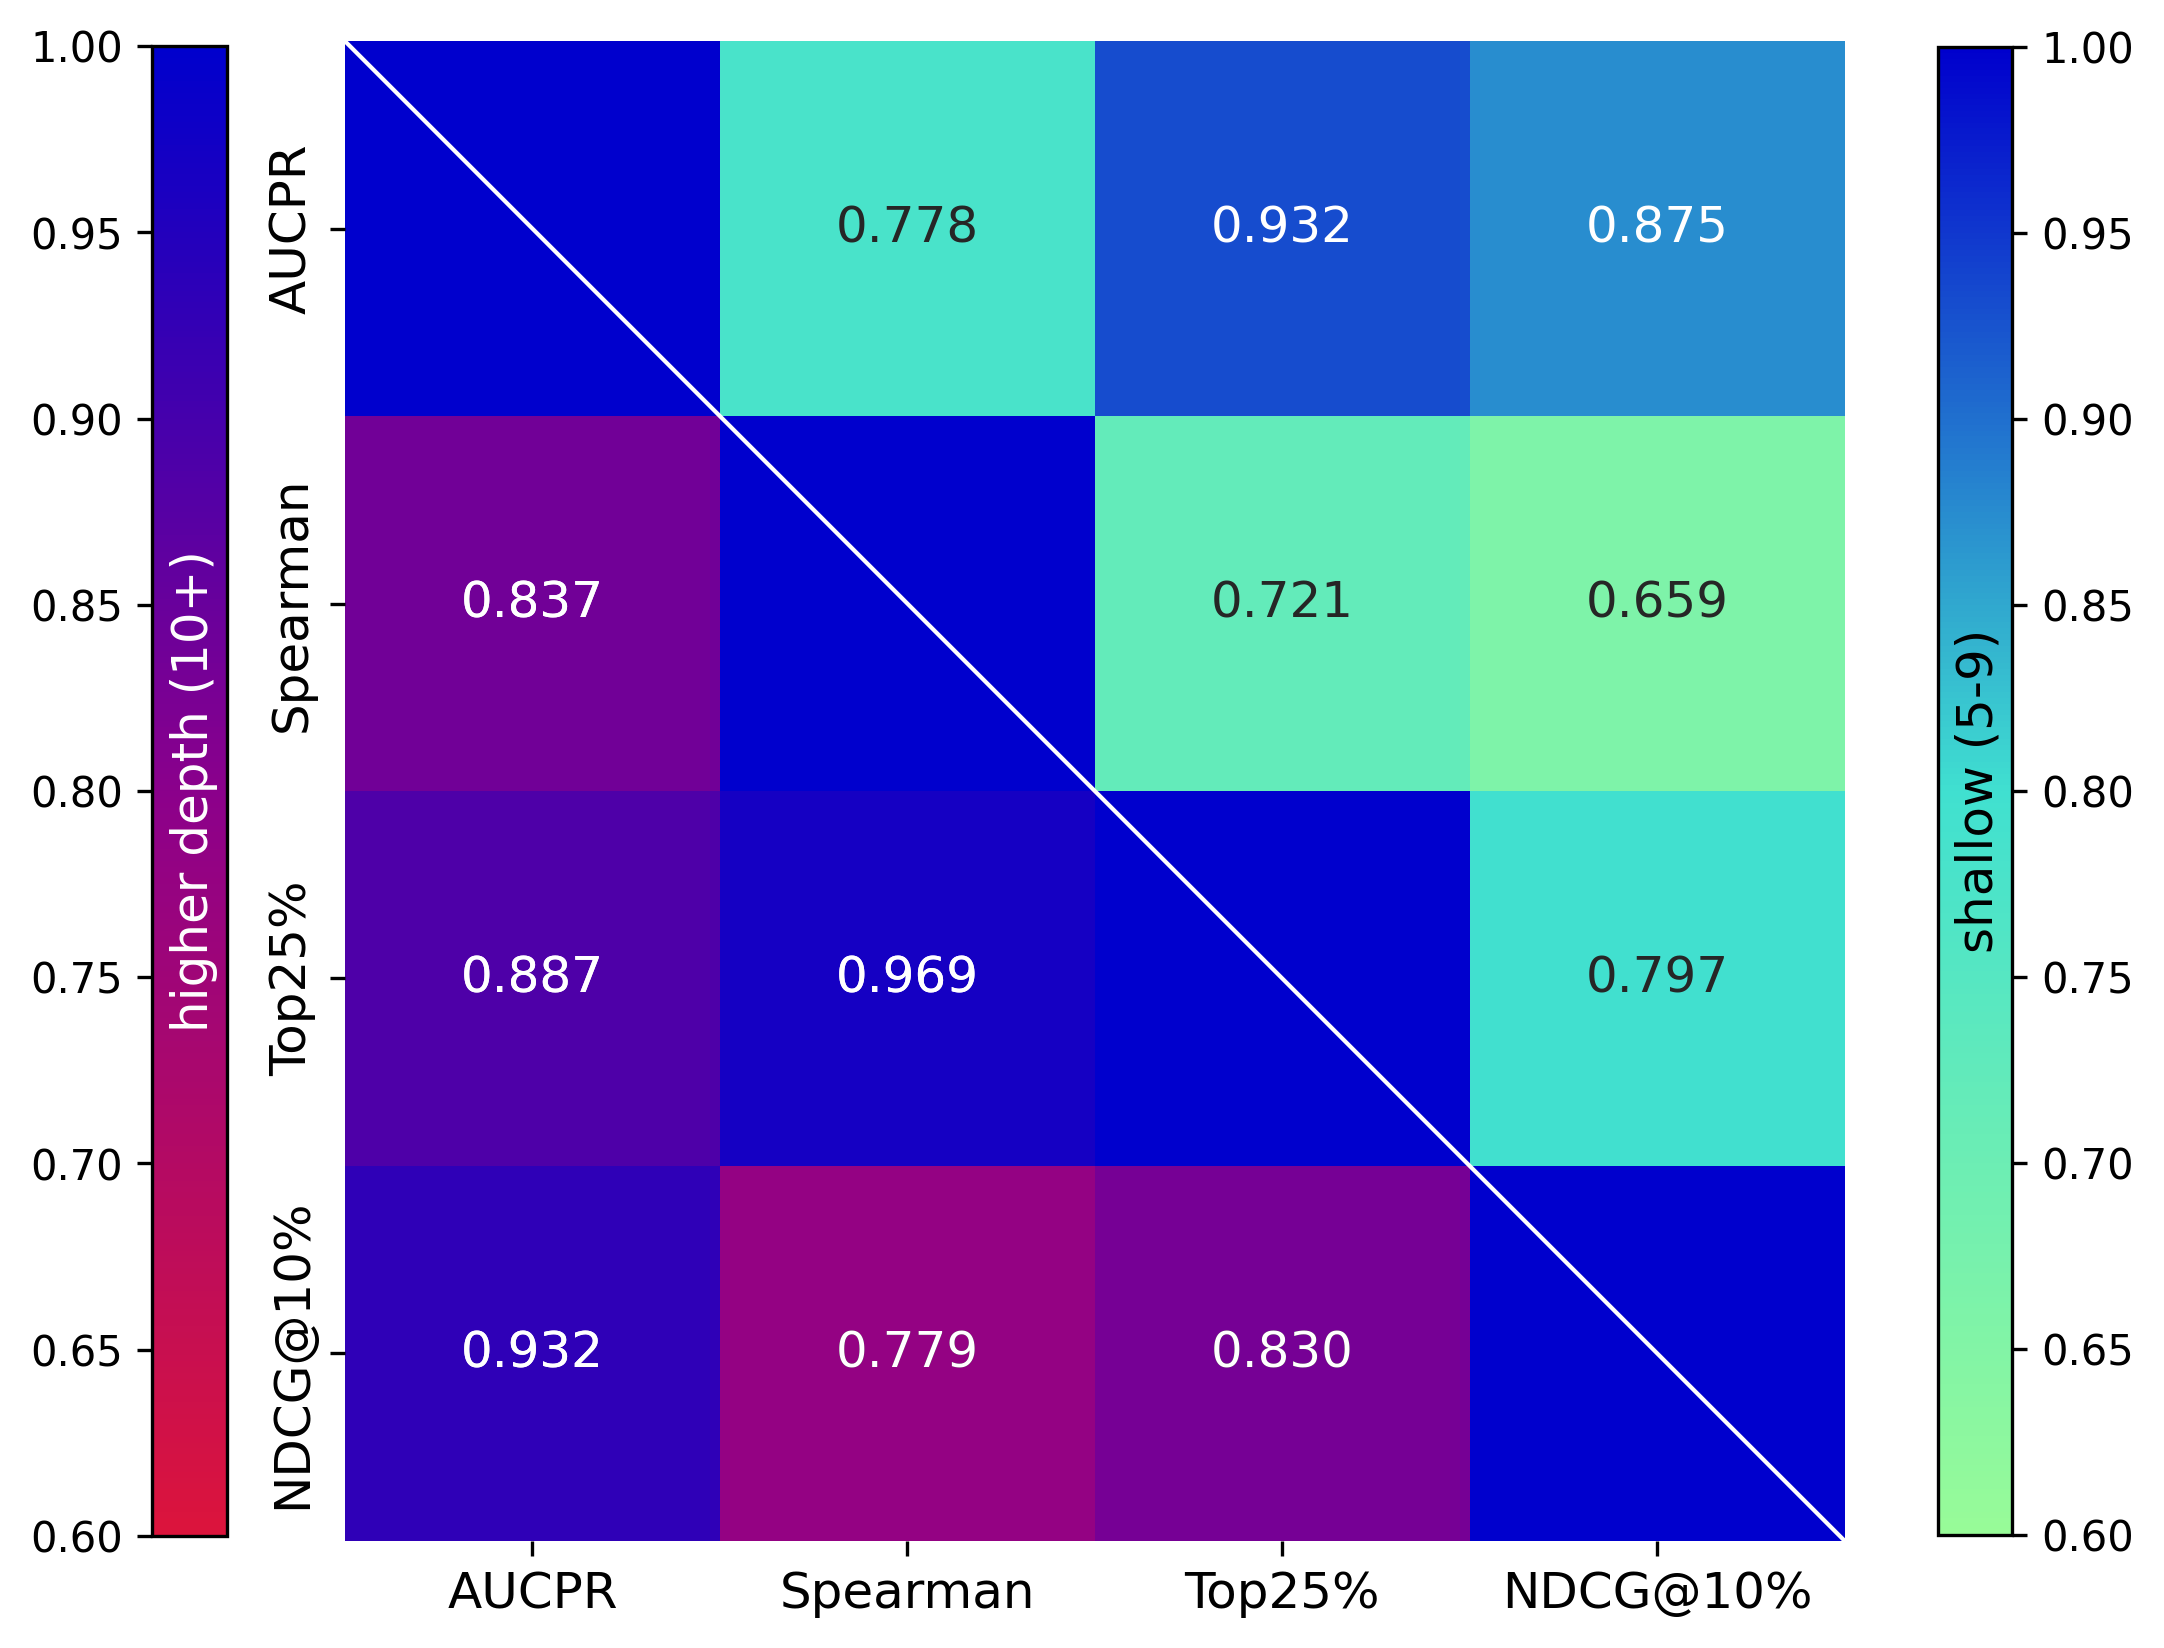

In [22]:
from matplotlib.colors import Normalize, LinearSegmentedColormap

np.random.seed(42)

cols = ['AUCPR', 'Spearman', 'Top25%', 'NDCG@10%']
n = len(cols)


# Create combined matrix
combined = np.zeros((n, n))

# Fill the matrix: lower left with shallow values, upper right with high_depth values
for i in range(n):
    for j in range(n):
        if i > j:  # Lower triangle (shallow)
            combined[i, j] = shallow.iloc[i, j]
        elif i < j:  # Upper triangle (high_depth)
            combined[i, j] = high_depth.iloc[i, j]
        else:  # Diagonal
            combined[i, j] = 1.0

# Create a DataFrame with the combined values
combined_df = pd.DataFrame(combined, index=cols, columns=cols)

# Create masks for upper and lower triangles
mask_upper = np.zeros_like(combined, dtype=bool)
mask_lower = np.zeros_like(combined, dtype=bool)
mask_diag = np.zeros_like(combined, dtype=bool)

# Fill masks
for i in range(n):
    for j in range(n):
        if i >= j:  # Lower triangle including diagonal
            mask_upper[i, j] = False
        if i <= j:  # Upper triangle including diagonal
            mask_lower[i, j] = True
        if i == j:  # Upper triangle including diagonal
            mask_upper[i, j] = True
        if i != j:  # Upper triangle including diagonal
            mask_diag[i, j] = True

# Create the figure and axes
plt.figure(figsize=(8, 7), dpi=300)

# Create custom colormaps
shallow_cm = LinearSegmentedColormap.from_list("shallow", ["crimson","darkmagenta", "mediumblue",])
deep_cm = LinearSegmentedColormap.from_list("deep", ["palegreen","turquoise", "mediumblue",])

# Plot the lower triangle (shallow data) with coolwarm colormap
ax1 = sns.heatmap(combined_df, mask=mask_upper, cmap=deep_cm, vmin=0.6, vmax=1,
                  annot=True, fmt='.3f', cbar=False, square=True, annot_kws={"size": 12})
ax1 = sns.heatmap(combined_df, mask=mask_diag, cmap=deep_cm, vmin=0.6, vmax=1,
                  annot=False, fmt='.3f', cbar=False, square=True, annot_kws={"size": 12})
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=12)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=12)
# Plot the upper triangle (high_depth data) with autumn colormap
ax2 = sns.heatmap(combined_df, mask=mask_lower, cmap=shallow_cm, vmin=0.6, vmax=1,
                  annot=True, fmt='.3f', cbar=False, square=True, annot_kws={"size": 12})

# for x in range(mask_upper.shape[0]):
#     ax1.text(x+0.7, x+0.3, '1.000', ha='center', va='center', fontsize=11, color = "white")
#     # Place bottom-left label
#     ax1.text(x+0.3, x+0.7, '1.000', ha='center', va='center', fontsize=11, color = "white")
ax1.plot([0, mask_upper.shape[0]], [0, mask_upper.shape[0]], color='white', lw=1)

from matplotlib.cm import ScalarMappable
norm = Normalize(vmin=0.6, vmax=1)
sm1 = ScalarMappable(norm=norm, cmap=deep_cm)
sm2 = ScalarMappable(norm=norm, cmap=shallow_cm)
cbar_s = plt.colorbar(sm1, ax=ax1, location='right', pad=0.05, fraction= 0.04, label='shallow (5-9)')
cbar_s.set_label('shallow (5-9)', labelpad=-43, fontsize=12)

cbar_d =plt.colorbar(sm2, ax=ax2, location='left', pad=0.07, fraction= 0.044, label='higher depth (10+)')
cbar_d.set_label('higher depth (10+)', labelpad=-45, fontsize=12, color = "white")
# plt.tight_layout()

# Display the plot
plt.show()

#### Pearson Correlation

Pearson Correlation are very high, all around 0.95.
The reason is that Pearson Correlation is very dependant on outliers. Here the baseline predictors (OHE and HBI) will be signifcantly worse than the more advanced models for all four metrics, leading to high correlations. 

In [23]:
shallow = res[res.depth == "shallow (5-9)"][['AUCPR', 'Spearman', 'Top25%', 'NDCG@10%']].corr()
shallow

,AUCPR,Spearman,Top25%,NDCG@10%
AUCPR,1.000000,0.986238,0.991302,0.994184
Spearman,0.986238,1.000000,0.997448,0.986860
Top25%,0.991302,0.997448,1.000000,0.989999
NDCG@10%,0.994184,0.986860,0.989999,1.000000


In [24]:
high_depth = res[res.depth == "higher depth (10+)"][['AUCPR', 'Spearman', 'Top25%', 'NDCG@10%']].corr()
high_depth

,AUCPR,Spearman,Top25%,NDCG@10%
AUCPR,1.000000,0.959453,0.984466,0.970008
Spearman,0.959453,1.000000,0.943353,0.934762
Top25%,0.984466,0.943353,1.000000,0.963436
NDCG@10%,0.970008,0.934762,0.963436,1.000000


### Fig. S3

In [12]:
# Function to determine positive vs. negative epistasis
def evaluate_mutations(row, mutation_dict, wt, offset=0):
    mutations = row['mutation_list']
    
    # Check if all mutations are in the dictionary
    if not all(mutation in mutation_dict for mutation in mutations):
        return np.nan  # If any mutation is missing, return NaN
    
    # Calculate the sum of the values for the present mutations
    sum_values = sum((mutation_dict[mutation] - wt) for mutation in mutations) + wt
    
    # Compare the sum to the DMS_score
    if row['DMS_score'] >= sum_values + offset:
        return 1
    elif row['DMS_score'] <= sum_values - offset:
        return -1
    else:
        return 0


def epistatic(file, wt):
    df = pd.read_csv("./data/raw/" + file + "/DMS_raw.csv", low_memory=False) 
    
    if 'log_delta' in df.columns:
        df['DMS_score'] = df['log_delta']


    df = df[df.set!="wt"] 
    print(file)

    # Evaluate mutations captured in training
    df_train = df[df.mutation_depth <= 1].copy()
    mutation_dict = df_train.set_index('mutant')['DMS_score'].to_dict()

    train = df[df.mutation_depth >1 ].copy().reset_index(drop=True)
    train.loc[:,'mutation_list'] = train["mutant"].str.split(':')

    # Apply the evaluation function to each row
    train['all_positive'] = train.apply(evaluate_mutations, axis=1, mutation_dict=mutation_dict, wt = wt, offset = df.DMS_score.std() *0.625)
    train = train.drop(columns=['mutation_list'])

    cutoff = get_cutoff(file)

    train.loc[train['mutation_depth'] >= cutoff, 'mutation_depth'] = cutoff

    return train


In [13]:
def print_epistasis(df, name):

    # Calculate the percentage for each new_column value (-1, 0, 1), grouped by mutation_depth
    percentage_df = df.groupby(['mutation_depth', 'all_positive']).size().unstack(fill_value=0)
    percentage_df = percentage_df.reindex(columns=[-1, 0, 1], fill_value=0)
    percentage_df = percentage_df.div(percentage_df.sum(axis=1), axis=0) * 100
   

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 3),dpi=300)

    # Create stacked bars for new_column
    percentage_df.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=['tab:red', "lightgrey",'tab:blue'])

    # Mapping new_column values to labels for legend
    labels = {1: 'positive', -1: 'negative', 0: "weak"}
    handles, _ = ax.get_legend_handles_labels()

    ax.legend(handles=handles, labels=[labels.get(int(label)) for label in percentage_df.columns],  loc='upper left', bbox_to_anchor=(1.0, 1.0), ncol=len(percentage_df.columns), title='Epistasis')

    plt.xlabel('Mutation Depth')
    
    # Use FuncFormatter to add a percentage sign
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    ax.set_ylim(0,100)

    ax.set_xticklabels(list(range(2, df.mutation_depth.max())) + [str(df.mutation_depth.max()) + '+'], rotation = 0)
    
    ax.set_title(name)

    plt.tight_layout()
    plt.show()

In [14]:
# wt for AAV = -0.918193710692946
# wt for GFP = 3.7192121319
# wt for YEAST = 1.0
# wt for CHLRE = 0 (using log_delta column instead of DMS_score)
wts = [-0.918193710692946,3.7192121319,1.0,0]
wts

[-0.918193710692946, 3.7192121319, 1.0, 0]

In [15]:
added_names = ["AAV Capsid", "GFP", "Dehydratase", "Phototropin"]

CAPSD_AAV2S_Sinai_2021
0 nan rows, which is 0.0 %


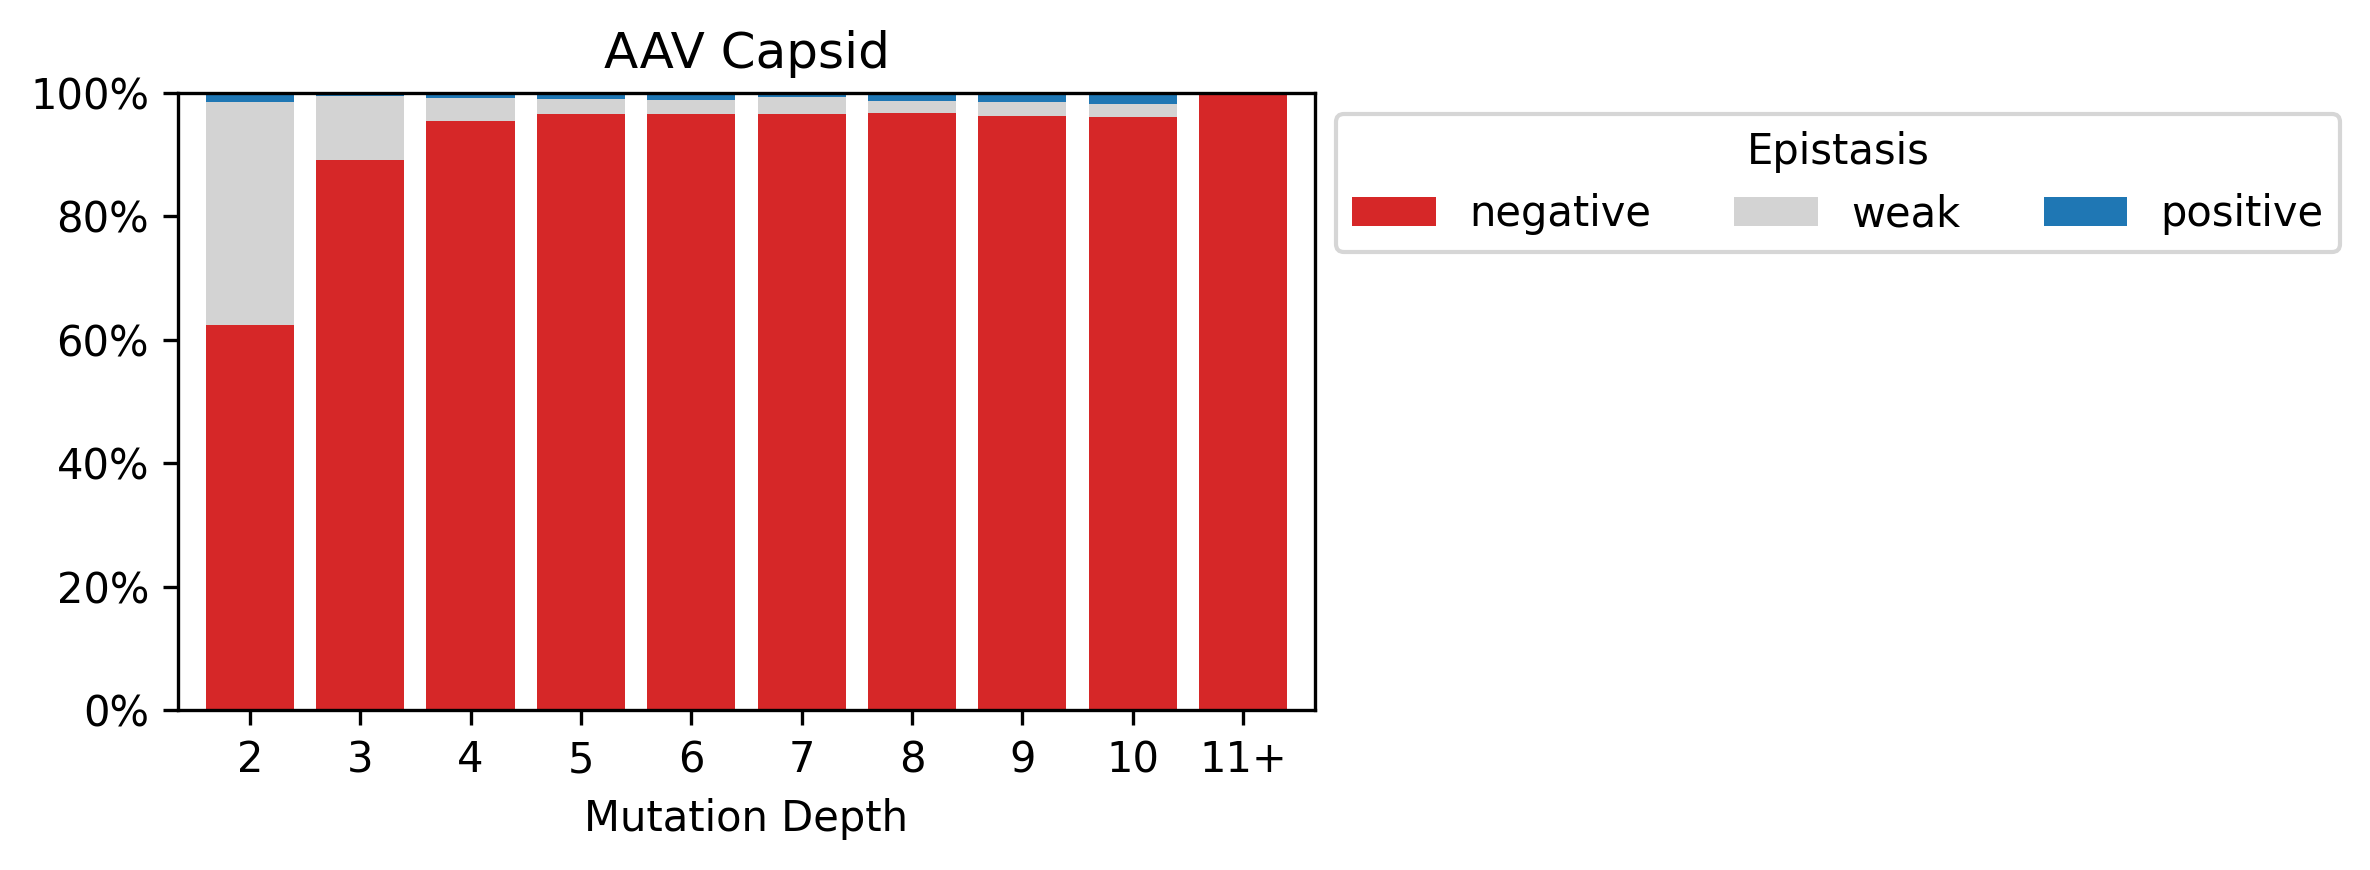

GFP_AEQVI_Sarkisyan_2016
7959 nan rows, which is 15.7 %


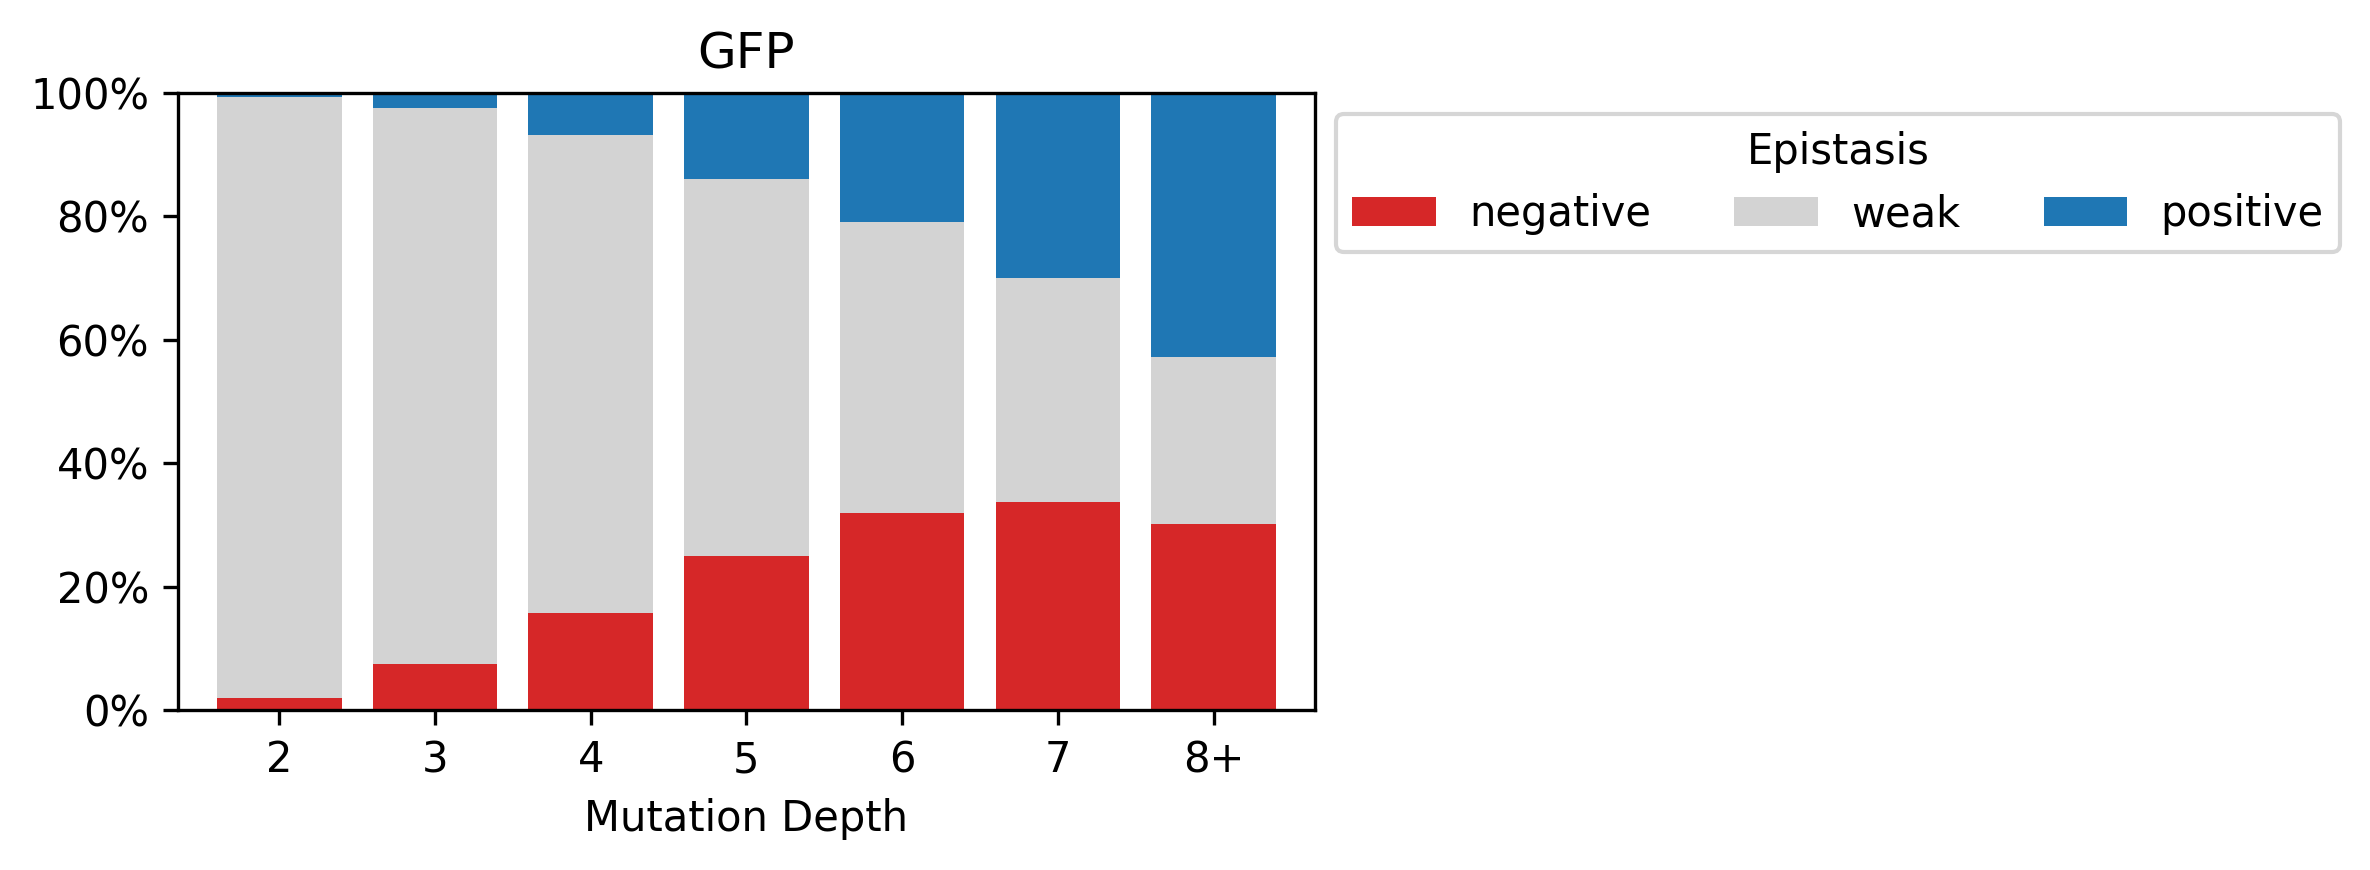

HIS7_YEAST_Pokusaeva_2019
241355 nan rows, which is 48.7 %


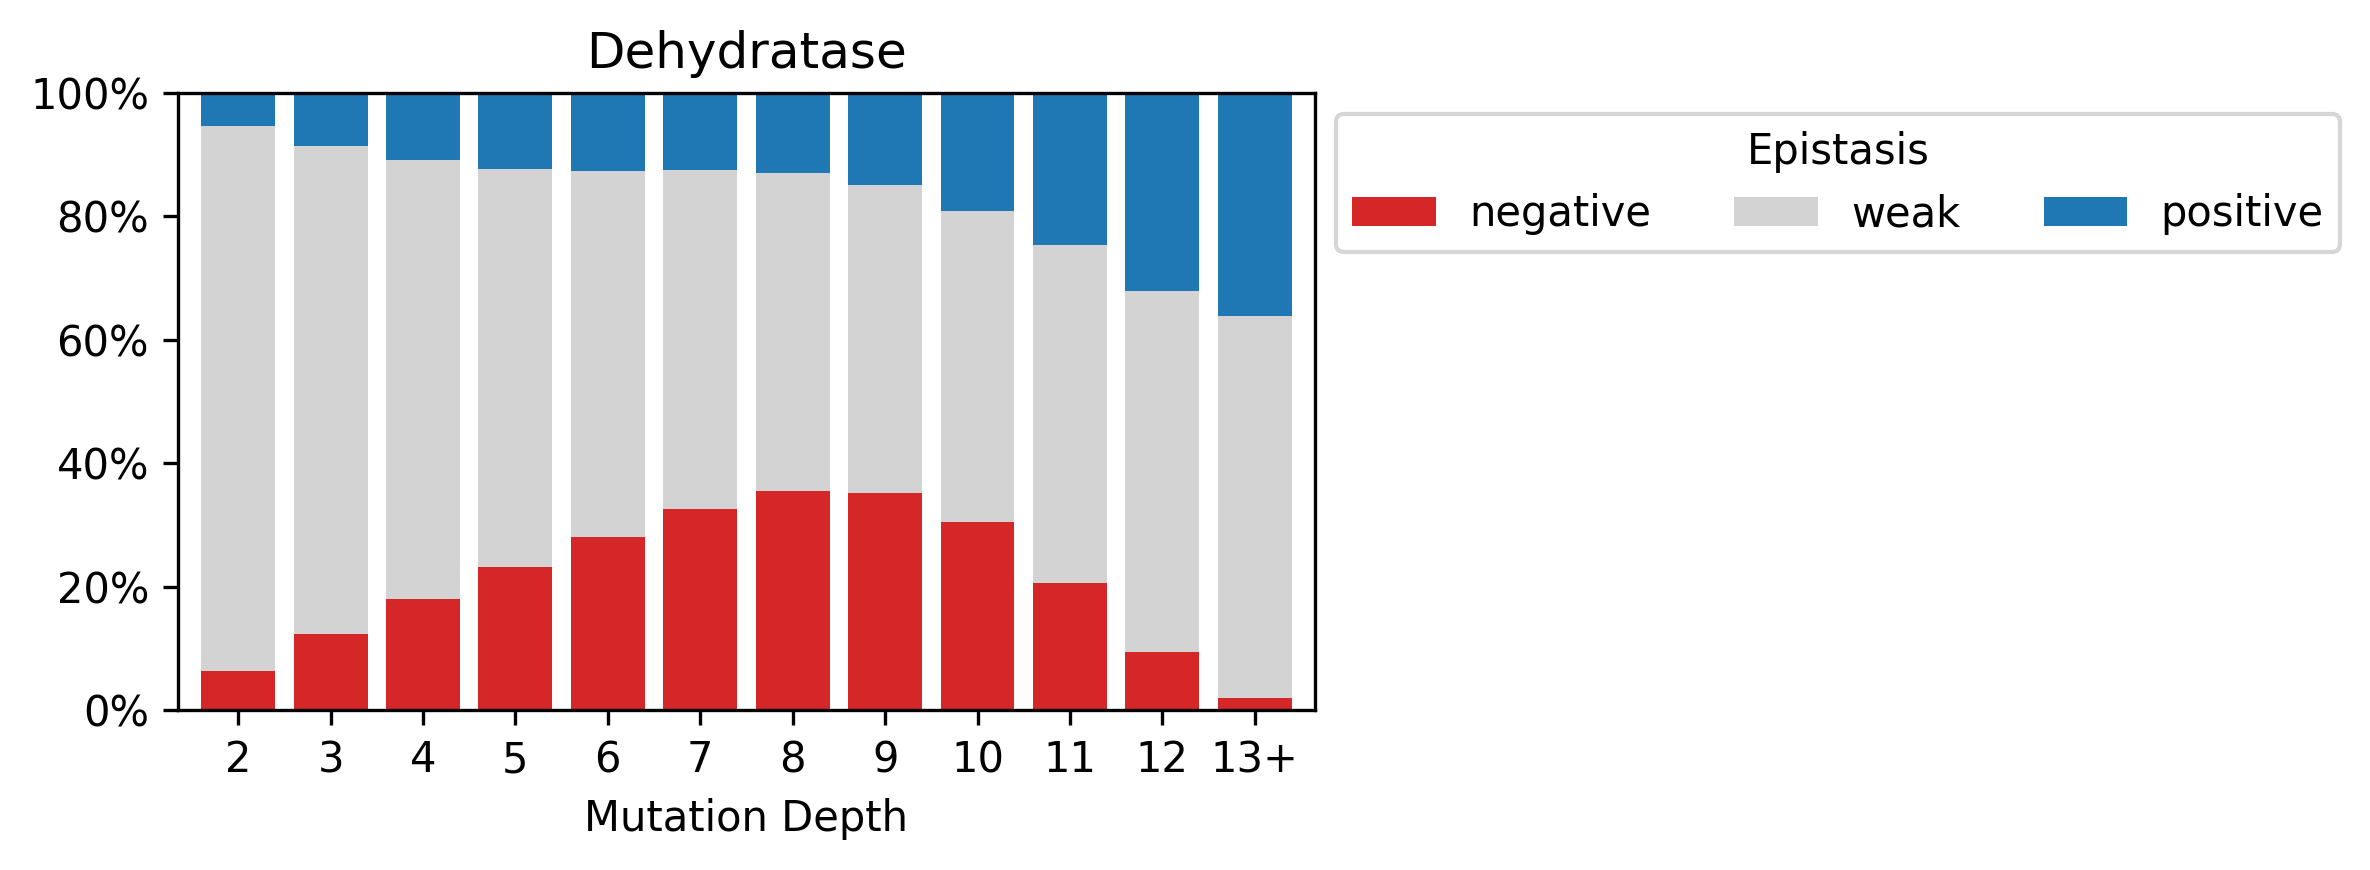

PHOT_CHLRE_Chen_2023
0 nan rows, which is 0.0 %


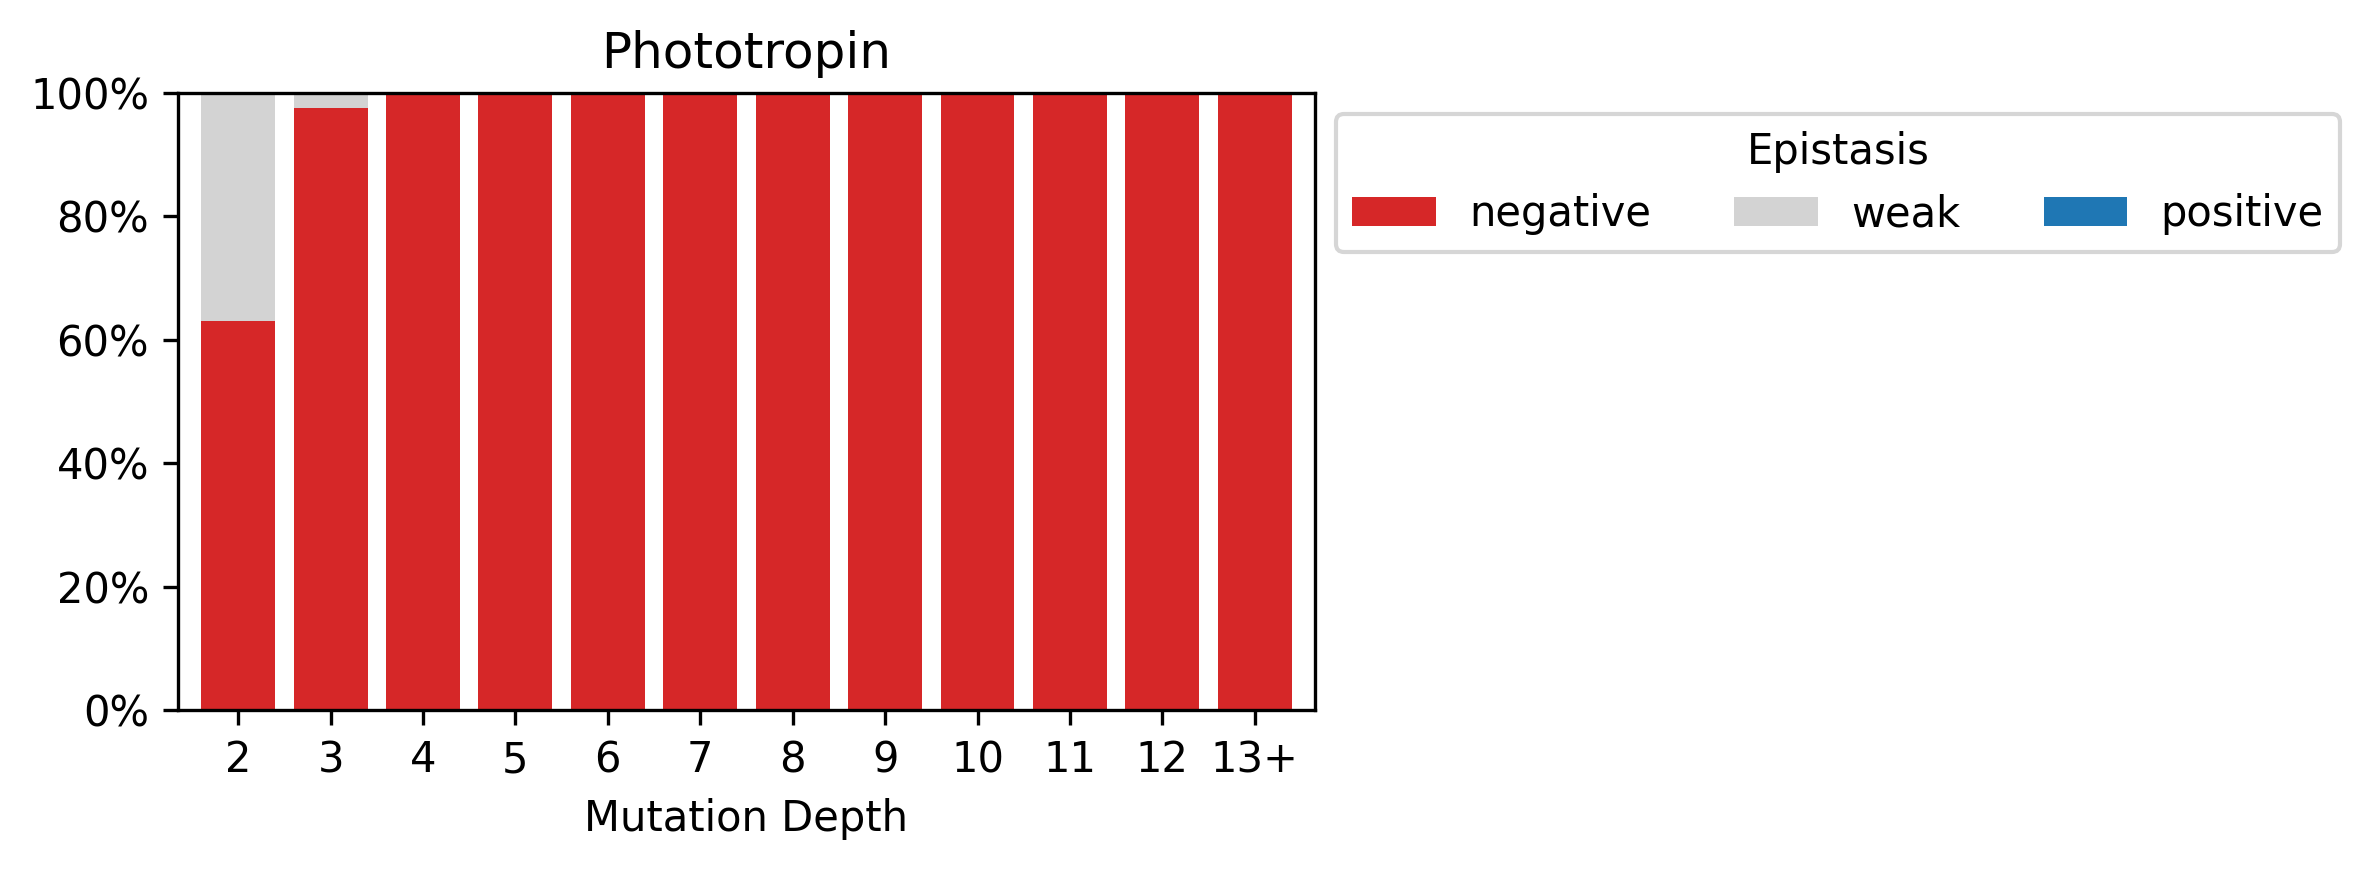

In [16]:
#all data
for f, wt, n in zip(files,wts, added_names):
    
    df = epistatic(f, wt)
    
    #number of rows where not all singletons are available
    print(len(df[df.all_positive.isna()]), "nan rows, which is", round(len(df[df.all_positive.isna()])/len(df)*100,1),"%")
    
    print_epistasis(df,n)

### Fig. S4

In [9]:
# Load the embedding from the .npy file
combined_array = np.load('./results/SOM/Embeddings_Fig_S4/embeddings.npy')

# Load the labels for the 1000 sequences
labels = np.load('./results/SOM/Embeddings_Fig_S4/labels.npy')

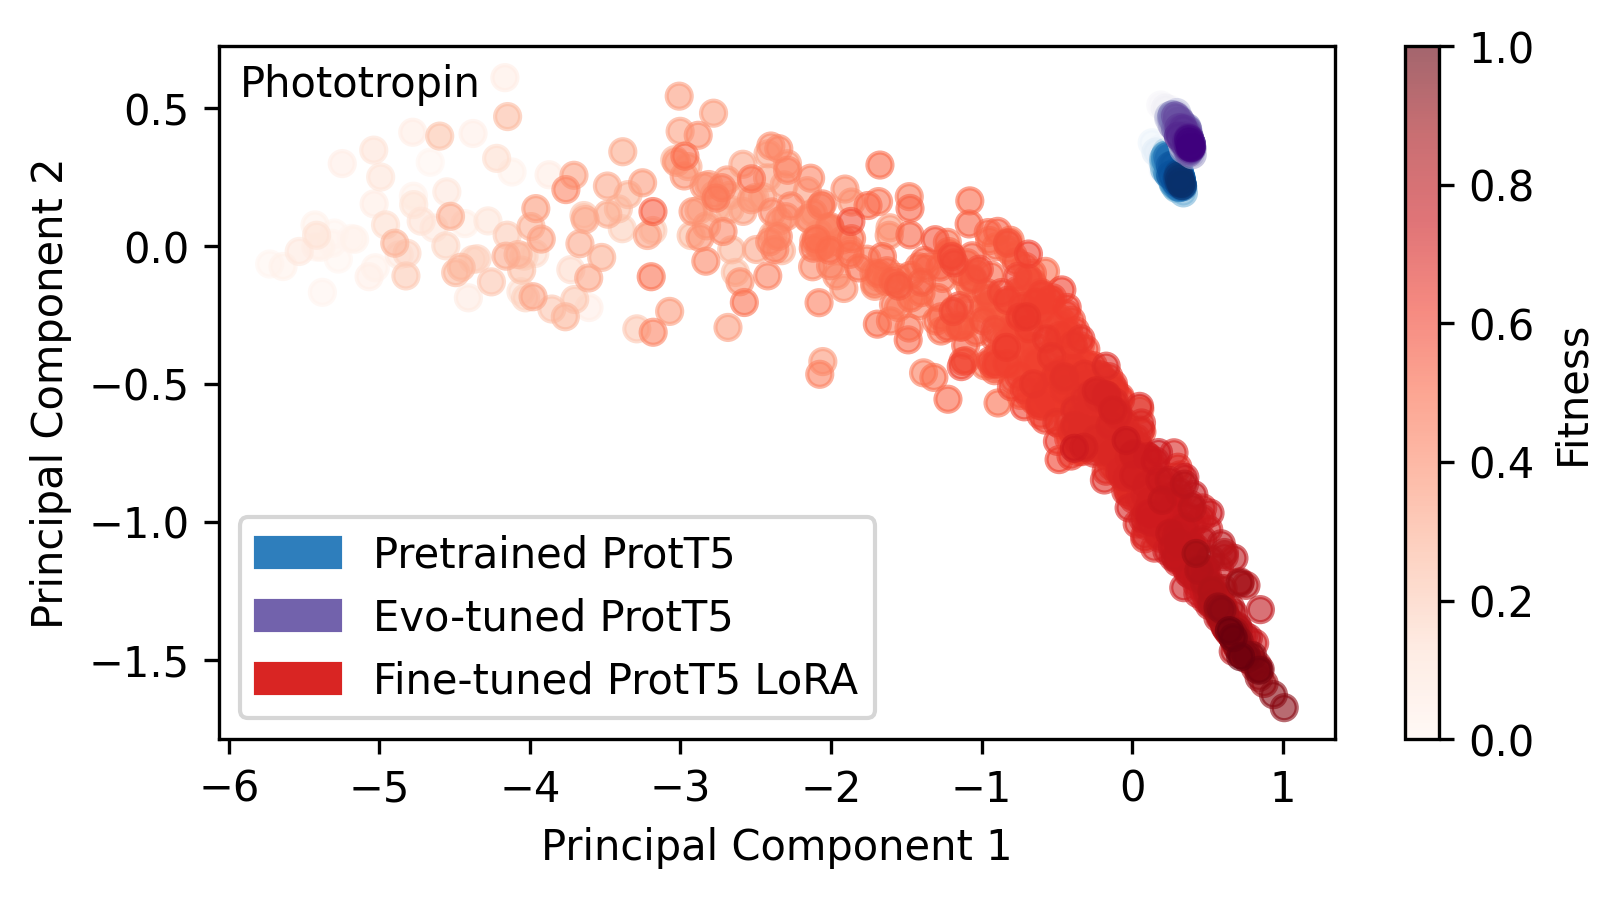

In [10]:
# # Perform PCA to reduce dimensions from 1024 to 2
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_array)

# Split the result back into parts for coloring purposes
# holds the same 1000 sequences/embeddings for each of 
# Pretrained ProtT5, Evo-tuned ProtT5 and Fine-tuned ProtT5 LoRA
pca_array1 = pca_result[0:1000]    # Pretrained ProtT5
pca_array2 = pca_result[1000:2000] # Evo-tuned ProtT5
pca_array3 = pca_result[2000:3000] # Fine-tuned ProtT5 LoRA

# Normalize these labels between 0 and 1 for color mapping
normalized_values = (labels - labels.min()) / (labels.max() - labels.min())

# Choose the colormap for shades of orange
cmap = plt.cm.Reds
cmap_e_1 = plt.cm.Purples
cmap_e_2  = plt.cm.Blues

# Plotting the PCA results
plt.figure(figsize=(6, 3),dpi=300)
plt.scatter(pca_array1[:, 0], pca_array1[:, 1], c=normalized_values, cmap=cmap_e_2, alpha=0.6)
plt.scatter(pca_array2[:, 0], pca_array2[:, 1], c=normalized_values, cmap=cmap_e_1, alpha=0.6)
plt.scatter(pca_array3[:, 0], pca_array3[:, 1], c=normalized_values, cmap=cmap, alpha=0.6)

# Create proxy artists for the legend
proxy_artist1 = mpatches.Patch(color=cmap_e_2(0.7), label='Pretrained ProtT5')
proxy_artist2 = mpatches.Patch(color=cmap_e_1(0.7), label='Evo-tuned ProtT5')
proxy_artist3 = mpatches.Patch(color=cmap(0.7), label='Fine-tuned ProtT5 LoRA')

# plt.title("Embeddings PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=[proxy_artist1, proxy_artist2, proxy_artist3]) 
plt.colorbar(label='Fitness')

plt.text(0.235, 0.975, 'Phototropin', ha='right', va='top', transform=plt.gca().transAxes)

plt.show()

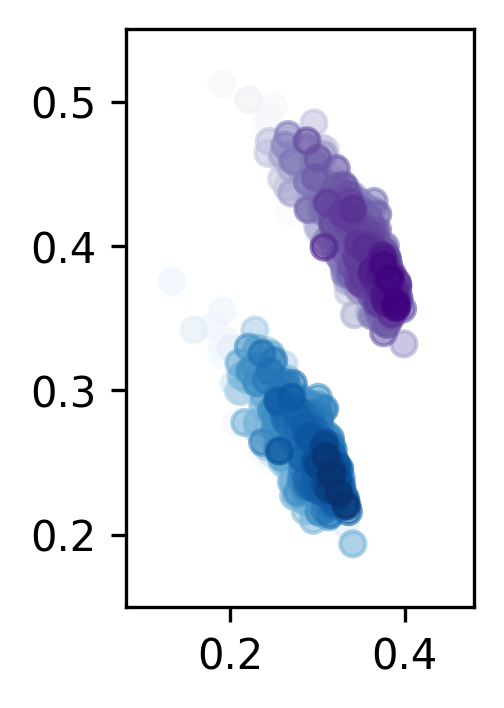

In [11]:
# Plotting the PCA results without fine-tuned
plt.figure(figsize=(1.5, 2.5),dpi=300)
plt.scatter(pca_array1[:, 0], pca_array1[:, 1], c=normalized_values, cmap=cmap_e_2, alpha=0.6)
plt.scatter(pca_array2[:, 0], pca_array2[:, 1], c=normalized_values, cmap=cmap_e_1, alpha=0.6)

# Create proxy artists for the legend
proxy_artist1 = mpatches.Patch(color=cmap_e_2(0.5), label='Pretrained ProtT5')
proxy_artist2 = mpatches.Patch(color=cmap_e_1(0.5), label='Continued Pretraining on CHLRE MSA')

plt.ylim(0.15, 0.55)
plt.yticks(np.arange(0.2, 0.6, 0.1))
plt.xlim(0.08, 0.48) 

plt.show()

## Tables

### Table S2-S5

In [25]:
def dataset_size(data):
    
    print(data)
    
    df_raw = pd.read_csv("./data/raw/" + data + "/DMS_raw.csv", low_memory=False) 

    df_raw = df_raw[df_raw.set!="wt"]    
    df_raw = df_raw.drop('mutated_sequence', axis=1)
    df_raw = df_raw.drop('set', axis=1)

    df_func = df_raw[df_raw.DMS_score_bin == 1].copy()
    
    if "ss" in data:
        buckets = [range(1,4), range(4,5), range(5,8), range(8,df_raw.mutation_depth.max()+1)]
        distance_wt  = ["1-3", "4", "5-7", "8-" + str(df_raw.mutation_depth.max())]
    else:
        buckets = [range(1,4), range(4,5), range(5,10), range(10,df_raw.mutation_depth.max()+1)]
        distance_wt  = ["1-3", "4", "5-9", "10-" + str(df_raw.mutation_depth.max())]
    split  = ["Training", "Validation", "Test", "Test"]



    res = pd.DataFrame(columns=["Split","Distance from wildtype", "Distance Bin","Number of seq","Number of functional seq","Share of functional seq"])

    for idx , b in enumerate(buckets):
        if idx == len(buckets) -1:
            if "GFP" in data:
                cutoff = 10
            else:
                cutoff = get_cutoff(data)

            for i in range(np.min(b),cutoff):
                new_row = pd.DataFrame([{'Split' : split[idx],
                                         "Distance from wildtype" : i,
                                         'Distance bin' : distance_wt[idx],
                                         'Number of seq' : len(df_raw[df_raw.mutation_depth == i]),
                                         'Number of functional seq' : len(df_func[df_func.mutation_depth == i]),
                                         'Share of functional seq' :  round(len(df_func[df_func.mutation_depth == i]) / 
                                                                         len(df_raw[df_raw.mutation_depth == i]),3) *100
                                        }])
                res = pd.concat([res.dropna(how='all', axis=1),new_row], ignore_index=True)
                
            new_row = pd.DataFrame([{'Split' : split[idx],
                                     "Distance from wildtype" : str(cutoff) + "-" + str(df_raw.mutation_depth.max()),
                                     'Distance bin' : distance_wt[idx],
                                     'Number of seq' : len(df_raw[df_raw.mutation_depth >= cutoff]),
                                     'Number of functional seq' : len(df_func[df_func.mutation_depth >= cutoff]),
                                     'Share of functional seq' :  round(len(df_func[df_func.mutation_depth >= cutoff]) / 
                                                                     len(df_raw[df_raw.mutation_depth >= cutoff]),3) *100
                                    }])            
            
            res = pd.concat([res.dropna(how='all', axis=1),new_row], ignore_index=True)            
        else:
            for i in range(np.min(b),np.max(b)+1):
                new_row = pd.DataFrame([{'Split' : split[idx],
                                         "Distance from wildtype" : i,
                                         'Distance bin' : distance_wt[idx],
                                         'Number of seq' : len(df_raw[df_raw.mutation_depth == i]),
                                         'Number of functional seq' : len(df_func[df_func.mutation_depth == i]),
                                         'Share of functional seq' :  round(len(df_func[df_func.mutation_depth == i]) / 
                                                                         len(df_raw[df_raw.mutation_depth == i]),3) *100
                                        }])
                res = pd.concat([res.dropna(how='all', axis=1),new_row], ignore_index=True)
                
    if "GFP" in data:
        res.loc[7:,"Distance bin"] = "8-15"
    
    return(res)
    


In [26]:
dataset_size(files[0])

CAPSD_AAV2S_Sinai_2021


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,532,315,59.2
1,Training,2,1-3,10833,4601,42.5
2,Training,3,1-3,6906,5177,75.0
3,Validation,4,4,6646,4504,67.8
4,Test,5,5-9,6298,3772,59.9
5,Test,6,5-9,5396,2584,47.9
6,Test,7,5-9,858,398,46.4
7,Test,8,5-9,739,237,32.1
8,Test,9,5-9,651,141,21.7
9,Test,10,10-28,583,92,15.8


In [27]:
dataset_size(files[1])

GFP_AEQVI_Sarkisyan_2016


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,1084,993,91.6
1,Training,2,1-3,12777,11367,89.0
2,Training,3,1-3,12336,9234,74.9
3,Validation,4,4,9387,5104,54.4
4,Test,5,5-9,6825,2284,33.5
5,Test,6,5-9,4298,802,18.7
6,Test,7,5-9,2526,229,9.1
7,Test,8,8-15,1364,61,4.5
8,Test,9,8-15,627,10,1.6
9,Test,10-15,8-15,490,2,0.4


In [28]:
dataset_size(files[2])

HIS7_YEAST_Pokusaeva_2019


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,168,162,96.4
1,Training,2,1-3,1475,1375,93.2
2,Training,3,1-3,7627,6661,87.3
3,Validation,4,4,25927,21177,81.7
4,Test,5,5-9,60263,45987,76.3
5,Test,6,5-9,98869,70269,71.1
6,Test,7,5-9,115751,76096,65.7
7,Test,8,5-9,97639,58953,60.4
8,Test,9,5-9,57139,32216,56.4
9,Test,10,10-28,22942,12488,54.4


In [29]:
dataset_size(files[3])

PHOT_CHLRE_Chen_2023


,Split,Distance from wildtype,Distance bin,Number of seq,Number of functional seq,Share of functional seq
0,Training,1,1-3,2122,1828,86.1
1,Training,2,1-3,176,168,95.5
2,Training,3,1-3,978,856,87.5
3,Validation,4,4,3565,2859,80.2
4,Test,5,5-9,9603,7015,73.1
5,Test,6,5-9,19193,12518,65.2
6,Test,7,5-9,29255,16938,57.9
7,Test,8,5-9,34230,17071,49.9
8,Test,9,5-9,30925,13010,42.1
9,Test,10,10-15,21167,7361,34.8


### Table S6

In [9]:
models = ["PT5-LoRA Rank.",
        "PT5-LoRA Rank. evo-tuned",
        "PT5-LoRA Rank. EVA-init"]

In [31]:
df = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_25", "NDCG@10"], main= False, percentage = False, digits = 3)
df

,method,depth,AUCPR,spearman_func,TOP_25,NDCG@10
0,PT5-LoRA Rank.,shallow (5-9),0.886 ± 0.025,0.544 ± 0.042,0.5 ± 0.043,0.853 ± 0.057
1,PT5-LoRA Rank.,higher depth (10+),0.744 ± 0.064,0.402 ± 0.104,0.396 ± 0.082,0.702 ± 0.289
2,PT5-LoRA Rank. evo-tuned,shallow (5-9),0.889 ± 0.026,0.554 ± 0.036,0.502 ± 0.039,0.851 ± 0.062
3,PT5-LoRA Rank. evo-tuned,higher depth (10+),0.74 ± 0.078,0.379 ± 0.046,0.394 ± 0.095,0.712 ± 0.223
4,PT5-LoRA Rank. EVA-init,shallow (5-9),0.889 ± 0.012,0.546 ± 0.032,0.505 ± 0.022,0.855 ± 0.039
5,PT5-LoRA Rank. EVA-init,higher depth (10+),0.716 ± 0.06,0.393 ± 0.086,0.388 ± 0.098,0.648 ± 0.132


### Table S7

In [32]:
models = ["PT5-LoRA Reg.",
        "PT5-LoRA Rank.",
        "PT5-LoRA Rank. contrastive",             
        "PT5-LoRA Rank. contrastive_onesided",
        "PT5-LoRA Rank. lambda_rank"]

In [33]:
# table 1
df = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_25", "NDCG@10"], main= False, percentage = False, digits = 3)
df

,method,depth,AUCPR,spearman_func,TOP_25,NDCG@10
0,PT5-LoRA Reg.,shallow (5-9),0.895 ± 0.027,0.53 ± 0.043,0.497 ± 0.047,0.853 ± 0.065
1,PT5-LoRA Reg.,higher depth (10+),0.747 ± 0.106,0.363 ± 0.081,0.392 ± 0.118,0.704 ± 0.189
2,PT5-LoRA Rank.,shallow (5-9),0.886 ± 0.025,0.544 ± 0.042,0.5 ± 0.043,0.853 ± 0.057
3,PT5-LoRA Rank.,higher depth (10+),0.744 ± 0.064,0.402 ± 0.104,0.396 ± 0.082,0.702 ± 0.289
4,PT5-LoRA Rank. contrastive,shallow (5-9),0.887 ± 0.027,0.543 ± 0.054,0.502 ± 0.042,0.855 ± 0.061
5,PT5-LoRA Rank. contrastive,higher depth (10+),0.731 ± 0.051,0.403 ± 0.073,0.394 ± 0.114,0.695 ± 0.138
6,PT5-LoRA Rank. contrastive_onesided,shallow (5-9),0.885 ± 0.013,0.532 ± 0.043,0.487 ± 0.037,0.851 ± 0.027
7,PT5-LoRA Rank. contrastive_onesided,higher depth (10+),0.731 ± 0.065,0.392 ± 0.137,0.367 ± 0.093,0.652 ± 0.176
8,PT5-LoRA Rank. lambda_rank,shallow (5-9),0.902 ± 0.013,0.542 ± 0.04,0.505 ± 0.035,0.889 ± 0.023
9,PT5-LoRA Rank. lambda_rank,higher depth (10+),0.764 ± 0.079,0.388 ± 0.128,0.406 ± 0.117,0.78 ± 0.152
